Grid strategy
1. comparing tech stock between them
2. comparing tech stocks with crypto
3. comparing results with S&P500 index

Analyze indicators for stocks. PE ratio, volume, revenue reports

Tasks:
1. add the grid percentage into the function
2. add the stock name into the function. Goal is to have a function that requires two arguments, one for the ticker, one for the grid distance

In [83]:
# getting data from yahoo finance, for the stock that I am interested in, for the last 5 years

import yfinance as yf
import pandas as pd

In [96]:
def get_stock_data(stock_symbol):
    # Define the ticker symbol
    ticker_symbol = stock_symbol

    # Get the data for the last 5 years
    stock_data = yf.download(ticker_symbol, period='1y')

    return stock_data

In [97]:
df_tsla = get_stock_data('TSLA')  # Example usage for Tesla

C:\Users\Avi\AppData\Local\Temp\ipykernel_26436\1078013031.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker_symbol, period='1y')
[*********************100%***********************]  1 of 1 completed


In [98]:
df_tsla.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2024-12-09,389.790009,404.799988,378.010010,397.609985,96359200
2024-12-10,400.989990,409.730011,390.850006,392.679993,97563600
2024-12-11,424.769989,424.880005,402.380005,409.700012,104287600
2024-12-12,418.100006,429.299988,415.000000,424.839996,87752200
2024-12-13,436.230011,436.299988,415.709991,420.000000,89000200


<Axes: xlabel='Date'>

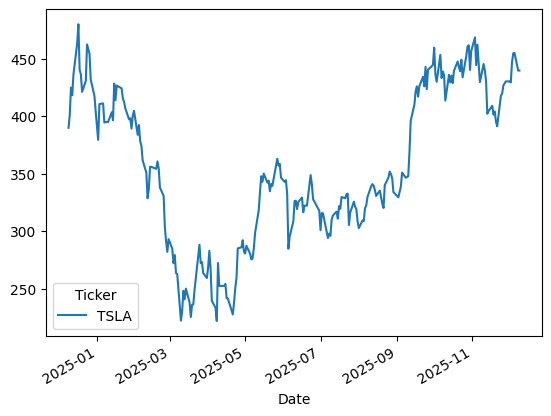

In [99]:
df_tsla.loc[:, 'Close'].plot()

In [100]:
df_tsla.index = df_tsla.index.date

In [101]:
#Analysis steps:
# for each day, if the price in in the current_stock_price +- 10%, then eiter sell, or buy. 
# if not, the go to next day

In [102]:
ls = []
price = df_tsla.loc[df_tsla.index.min(),'Open']
price = price.item()
print(ls.append(price))
print(ls)

None
[397.6099853515625]


In [103]:
len(df_tsla.index)

251

In [104]:
range(len(df_tsla.index))

range(0, 251)

In [105]:
# get the open price from the first day
positions_open = []
positions_closed = []
first_stock_price = df_tsla.loc[df_tsla.index.min(),'Open'].item()
positions_open.append(first_stock_price)
for day_num in range(len(df_tsla.index)-1):
    # if the price * 10% is between the next day's low and high price, then add the new price to a list, as a list, with the price and date. same if it's lower with 10%, add it to a list
    next_day_low_price = df_tsla.iloc[day_num+1, 2].item()
    next_day_high_price = df_tsla.iloc[day_num+1, 1].item()
    #print(f"Day is: {day_num}, next day low price is: {next_day_low_price}, next day high price is: {next_day_high_price}")
    for position in positions_open:
        #print(f"trade open: {position}, total positions open: {positions_open}, position*1.1: {position*1.1}, position*0.9: {position*0.9} ")
        if position*1.1 >= next_day_low_price and position*1.1 <= next_day_high_price:
            #sell and add in list
            positions_closed.append(position*1.1)
            #print(f"positions closed list: {positions_closed}")
            positions_open.append(position*1.1)
            #print(f"positions open list: {positions_open}")
            positions_open.remove(position)
        if min(positions_open)*0.9 >= next_day_low_price and min(positions_open)*0.9 <= next_day_high_price:
        # these will become two dataframes, with the date and value of taking profit and buying
            if min(positions_open)*0.9 not in positions_open: 
                positions_open.append(min(positions_open)*0.9)
        if position*1.1 < next_day_low_price:
            positions_closed.append(position*1.1)
            positions_open.append(next_day_low_price)
            positions_open.remove(position)

In [107]:
len(positions_closed)

SyntaxError: invalid syntax (1822151317.py, line 1)